# And now... We analyse (and chart)
This notebook is where we do the analysis that we can see. For the other notebooks, I kept using the .parquet file I got from the Data Collector notebook, but in this one I'll be creating my own query using the functions I've displayed across the other notebooks. If I wanted to use the .parquet file, or if I wanted shot data from multiple seasons, all I'd have to do is read a created file from data (like I did on the scratchpad), and work from there.

Querying shot data for LeBron James with context 'FGA' in Regular Season of 2010-11 season...
[0]	validation_0-logloss:0.68661
[1]	validation_0-logloss:0.67931
[2]	validation_0-logloss:0.67367
[3]	validation_0-logloss:0.66935
[4]	validation_0-logloss:0.66496
[5]	validation_0-logloss:0.66037
[6]	validation_0-logloss:0.65731
[7]	validation_0-logloss:0.65470
[8]	validation_0-logloss:0.65264
[9]	validation_0-logloss:0.64983
[10]	validation_0-logloss:0.64664
[11]	validation_0-logloss:0.64452
[12]	validation_0-logloss:0.64171
[13]	validation_0-logloss:0.63961
[14]	validation_0-logloss:0.63686
[15]	validation_0-logloss:0.63478
[16]	validation_0-logloss:0.63279
[17]	validation_0-logloss:0.63067
[18]	validation_0-logloss:0.62968
[19]	validation_0-logloss:0.62931
[20]	validation_0-logloss:0.62937
[21]	validation_0-logloss:0.62824
[22]	validation_0-logloss:0.62873
[23]	validation_0-logloss:0.62766
[24]	validation_0-logloss:0.62652
[25]	validation_0-logloss:0.62635
[26]	validation_0-logloss:0.6257

c:\Users\rukev\Documents\Projects\Shooters_Shoot\src\vis.py:88: UserWarning: You passed a edgecolor/edgecolors ('white') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


Shot chart saved to ../images/LeBron James_2010-11_shot_chart.png
xFG heatmap saved to ../images/LeBron James_2010-11_xfg_heatmap.png


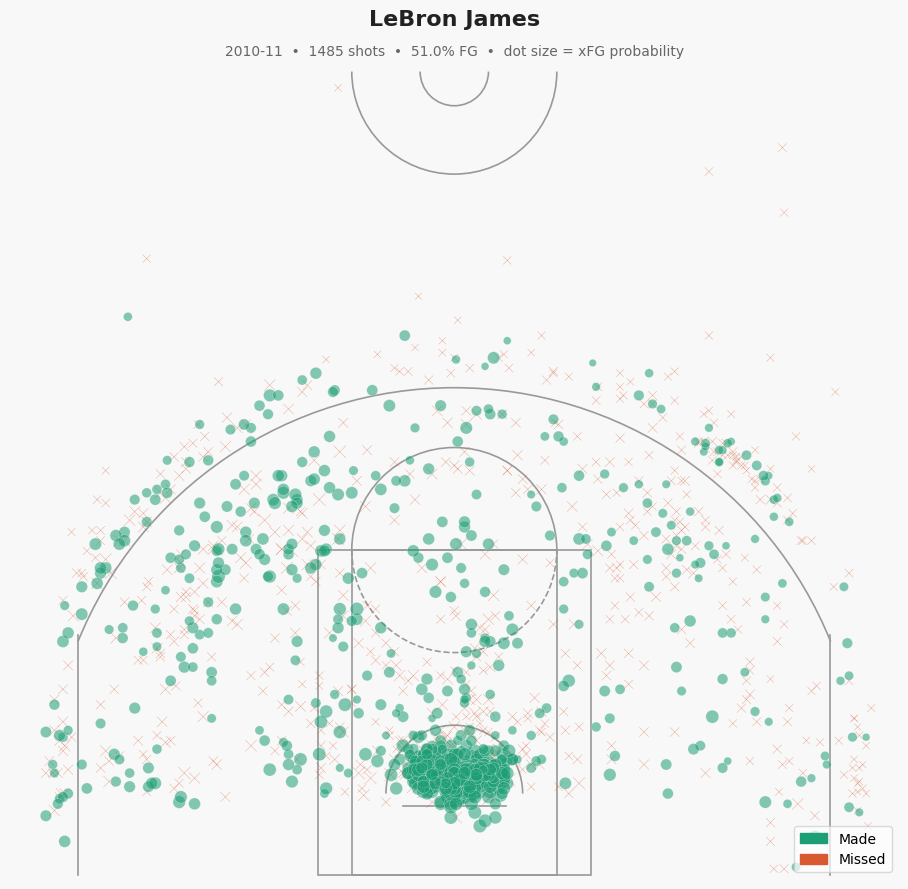

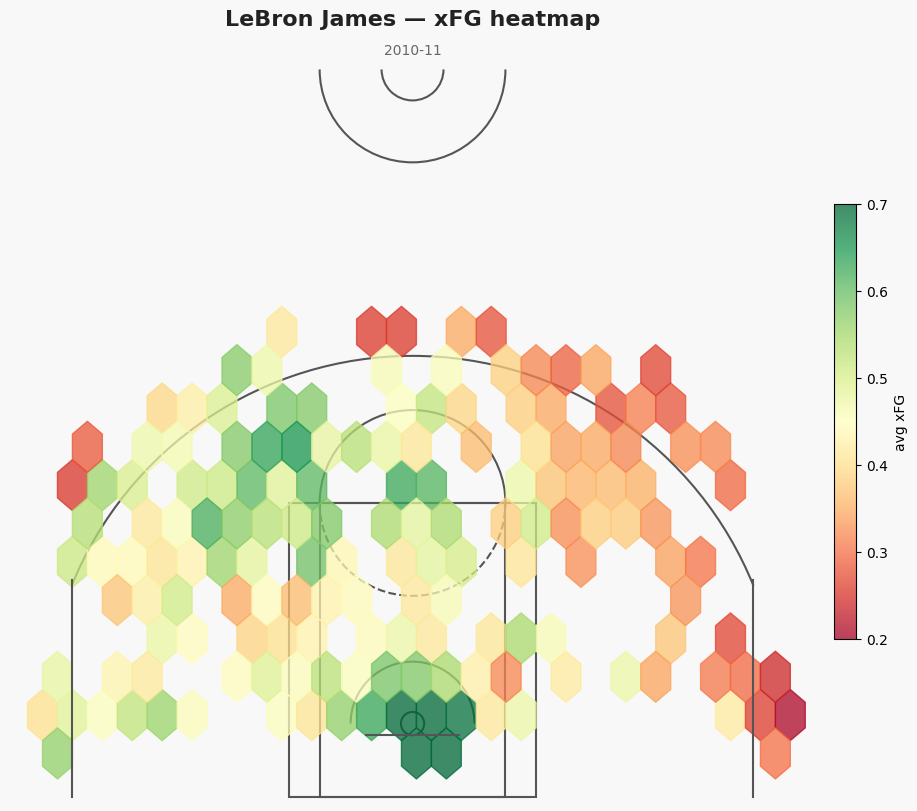

In [5]:
import sys, os
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
sys.path.insert(0, os.path.abspath('..'))
from src.consts import *
from src.model import train_model, evaluate_model, predict
from src.features import get_coords
from src.data_fetcher import fetch_shot_data, get_team_id, get_player_id, format_season
from src.vis import plot_shot_chart, plot_xfg_heatmap

# Getters and Fetchers
player_name = input("Enter player name (or 'all' for all players): ")
team_name = input("Enter team name (or 'all' for all teams): ")
year = input("Enter season year (e.g., 2020 for 2020-2021 season): ")
season_type = input("Enter season type (Regular Season or Playoffs): ")
context = input("Enter context(e.g., FGA, 3PA, etc.): ")

season_type_map = { 'Regular Season': 'Regular Season', 'Regular': 'Regular Season', 'Playoffs': 'Playoffs' }
season_type_mapped = season_type_map.get(season_type, season_type)
context_map = { 'FGA': 'FGA', '3PA': 'FG3A', 'FGM': 'FGM', '3PM': 'FG3M' }
context_measure_simple = context_map.get(context.upper(), context)

player_id = get_player_id(player_name)
team_id = get_team_id(team_name)   
season = format_season(year)
print(f"Querying shot data for {player_name} with context '{context_measure_simple}' in {season_type_mapped} of {season} season...")
df = fetch_shot_data(player_id, team_id, season, season_type_mapped, context_measure_simple)

# Feature Engineering
X, y = get_coords(df)

# Model Training and Evaluation
model, X_test, Y_test = train_model(X, y)
evaluate_model(model, X_test, Y_test)
os.makedirs('../models', exist_ok=True)
xgb.sklearn.XGBModel.save_model(model, f'../models/{player_name}_{season}_model.json')

#Analysis and Visualization
df['xFG'] = predict(model, X)
os.makedirs('../images', exist_ok=True)
plot_shot_chart(df, player_name=player_name, season_label=season, save_path=f'../images/{player_name}_{season}_shot_chart.png')
plot_xfg_heatmap(df, player_name=player_name, season_label=season, save_path=f'../images/{player_name}_{season}_xfg_heatmap.png')
plt.show()